# CDS change type alluvial (Ensembl → CAT)
Protein-coding only; grouped to 5 categories by default.

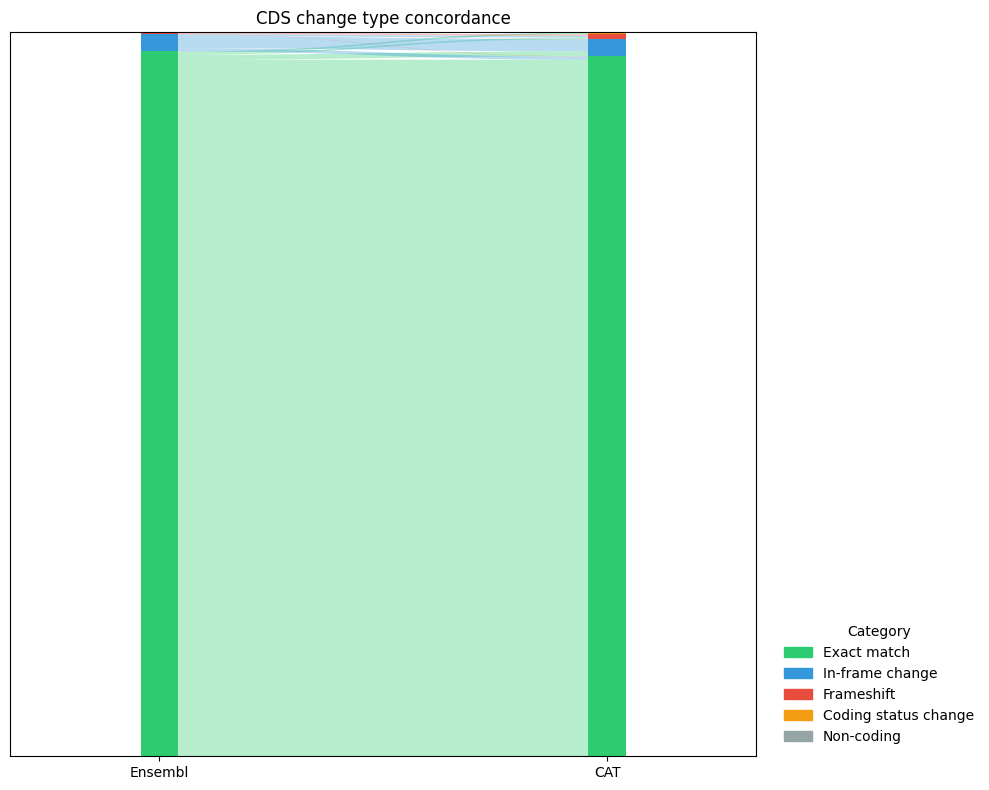

Saved figures/figure_main2_cds_alluvial_grouped.png


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

RESULTS_DIR = Path('/hps/nobackup/flicek/ensembl/genebuild/jackt/hprc/hprc-qc/results')
DIV_DIR = RESULTS_DIR / 'intermediate_spreadsheets' / 'divergence'
OUTPUT_DIR = Path('figures')
OUTPUT_DIR.mkdir(exist_ok=True)

GROUPED = True  # toggle to False for 8-type view

GROUP_MAP = {
    'exact_match':        'Exact match',
    'in_frame_shorter':   'In-frame change',
    'in_frame_longer':    'In-frame change',
    'frameshift_shorter': 'Frameshift',
    'frameshift_longer':  'Frameshift',
    'coding_lost':        'Coding status change',
    'coding_gained':      'Coding status change',
    'non_coding':         'Non-coding',
}
GROUP_ORDER  = ['Exact match', 'In-frame change', 'Frameshift', 'Coding status change', 'Non-coding']
GROUP_COLORS = {
    'Exact match':          '#2ecc71',
    'In-frame change':      '#3498db',
    'Frameshift':           '#e74c3c',
    'Coding status change': '#f39c12',
    'Non-coding':           '#95a5a6',
}

ct_path = DIV_DIR / 'grch38_cds_change_type_cross_tab.tsv'
ct = pd.read_csv(ct_path, sep='\t')
pc = ct[ct['biotype'] == 'protein_coding'].copy()

# ─────────────────────────────────────────────
# Build grouped or ungrouped table
# ─────────────────────────────────────────────
if GROUPED:
    pc['ens_group'] = pc['ens_cds_change_type'].map(GROUP_MAP)
    pc['cat_group'] = pc['cat_cds_change_type'].map(GROUP_MAP)
    rows = pc.groupby(['ens_group', 'cat_group'])['count'].sum().reset_index()

    ens_labels = GROUP_ORDER.copy()
    cat_labels = GROUP_ORDER.copy()

    ens_color_map = GROUP_COLORS.copy()
    cat_color_map = GROUP_COLORS.copy()

    title = 'CDS change type concordance'
    EXACT = 'Exact match'
else:
    rows = pc.groupby(['ens_cds_change_type', 'cat_cds_change_type'])['count'].sum().reset_index()

    # Keep stable, readable ordering: ENS order first seen; CAT order first seen
    ens_labels = pd.Index(rows['ens_cds_change_type']).drop_duplicates().tolist()
    cat_labels = pd.Index(rows['cat_cds_change_type']).drop_duplicates().tolist()

    # Separate colour maps (so legends can differ). If you want distinct palettes, change these.
    ens_color_map = {k: '#3498db' for k in ens_labels}
    cat_color_map = {k: '#9b59b6' for k in cat_labels}

    title = 'CDS change type concordance (8 types, protein-coding)'
    EXACT = 'exact_match'

# ─────────────────────────────────────────────
# DROP exact→exact ONLY (keep exact on each side otherwise)
# ─────────────────────────────────────────────
# if GROUPED:
#     rows = rows[~((rows['ens_group'] == EXACT) & (rows['cat_group'] == EXACT))].copy()
# else:
#     rows = rows[~((rows['ens_cds_change_type'] == EXACT) &
#                   (rows['cat_cds_change_type'] == EXACT))].copy()

# ─────────────────────────────────────────────
# Pivot to matrix
# ─────────────────────────────────────────────
pivot = rows.pivot_table(index=rows.columns[0],
                         columns=rows.columns[1],
                         values='count',
                         fill_value=0)

pivot = pivot.reindex(index=ens_labels, columns=cat_labels, fill_value=0)
total = float(pivot.values.sum())

# ─────────────────────────────────────────────
# Compute cumulative ranges along y for the two vertical bars
# ─────────────────────────────────────────────
def cumulative_ranges(totals, grand_total):
    ranges, cursor = {}, 0.0
    for lab, v in totals.items():
        f = (float(v) / grand_total) if grand_total > 0 else 0.0
        ranges[lab] = (cursor, cursor + f)
        cursor += f
    return ranges

ens_totals = {lab: float(pivot.loc[lab].sum()) if lab in pivot.index else 0.0 for lab in ens_labels}
cat_totals = {lab: float(pivot[lab].sum())     if lab in pivot.columns else 0.0 for lab in cat_labels}

ens_ranges = cumulative_ranges(ens_totals, total)
cat_ranges = cumulative_ranges(cat_totals, total)

# ─────────────────────────────────────────────
# Plot
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
X_ENS, X_CAT, BAR_W = 0.2, 0.8, 0.05

# Bars (now BOTH sides coloured by their own maps)
for lab, (lo, hi) in ens_ranges.items():
    ax.bar(
        x=X_ENS, height=hi-lo, width=BAR_W, bottom=lo,
        color=ens_color_map.get(lab, '#95a5a6'),
        align='center'
    )

for lab, (lo, hi) in cat_ranges.items():
    ax.bar(
        x=X_CAT, height=hi-lo, width=BAR_W, bottom=lo,
        color=cat_color_map.get(lab, '#bdc3c7'),
        align='center'
    )

# ─────────────────────────────────────────────
# Ribbons
# ─────────────────────────────────────────────
from matplotlib.path import Path as MplPath
from matplotlib.patches import PathPatch
import matplotlib.patches as mpatches

ens_cursor = {k: v[0] for k, v in ens_ranges.items()}
cat_cursor = {k: v[0] for k, v in cat_ranges.items()}

for e in ens_labels:
    for c in cat_labels:
        if (e not in pivot.index) or (c not in pivot.columns):
            continue
        cnt = float(pivot.loc[e, c])
        if cnt <= 0:
            continue

        frac = (cnt / total) if total > 0 else 0.0

        e_lo, e_hi = ens_cursor[e], ens_cursor[e] + frac
        c_lo, c_hi = cat_cursor[c], cat_cursor[c] + frac
        ens_cursor[e] = e_hi
        cat_cursor[c] = c_hi

        cx = (X_ENS + X_CAT) / 2.0

        verts = [
            (X_ENS + BAR_W/2, e_lo),
            (cx,             e_lo),
            (cx,             c_lo),
            (X_CAT - BAR_W/2, c_lo),
            (X_CAT - BAR_W/2, c_hi),
            (cx,              c_hi),
            (cx,              e_hi),
            (X_ENS + BAR_W/2,  e_hi),
            (X_ENS + BAR_W/2,  e_lo),
        ]
        codes = [
            MplPath.MOVETO,
            MplPath.CURVE4, MplPath.CURVE4, MplPath.CURVE4,
            MplPath.LINETO,
            MplPath.CURVE4, MplPath.CURVE4, MplPath.CURVE4,
            MplPath.CLOSEPOLY,
        ]

        ax.add_patch(PathPatch(
            MplPath(verts, codes),
            facecolor=ens_color_map.get(e, '#95a5a6'),  # colour by ENS category
            edgecolor='none',
            alpha=0.35,
            zorder=0
        ))

# ─────────────────────────────────────────────
# Axes / title
# ─────────────────────────────────────────────
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xticks([X_ENS, X_CAT])
ax.set_xticklabels(['Ensembl', 'CAT'])
ax.set_yticks([])
ax.set_title(title)

# ─────────────────────────────────────────────
# Two legends (ENS + CAT)
# ─────────────────────────────────────────────
ens_leg_labels = [lab for lab in ens_labels if lab in ens_color_map]
cat_leg_labels = [lab for lab in cat_labels if lab in cat_color_map]

ens_handles = [mpatches.Patch(color=ens_color_map[lab], label=lab) for lab in ens_leg_labels]
cat_handles = [mpatches.Patch(color=cat_color_map[lab], label=lab) for lab in cat_leg_labels]

# leg1 = ax.legend(
#     handles=ens_handles,
#     title="Ensembl category",
#     loc="upper left",
#     bbox_to_anchor=(1.02, 1.0),
#     frameon=False
# )
# ax.add_artist(leg1)

ax.legend(
    handles=cat_handles,
    title="Category",
    loc="lower left",
    bbox_to_anchor=(1.02, 0.0),
    frameon=False
)

plt.tight_layout()

out = OUTPUT_DIR / (
    'figure_main2_cds_alluvial_grouped.png'
    if GROUPED else
    'figure_main2_cds_alluvial_ungrouped.png'
)

plt.savefig(out, dpi=300, bbox_inches='tight')
plt.show()

print('Saved', out)

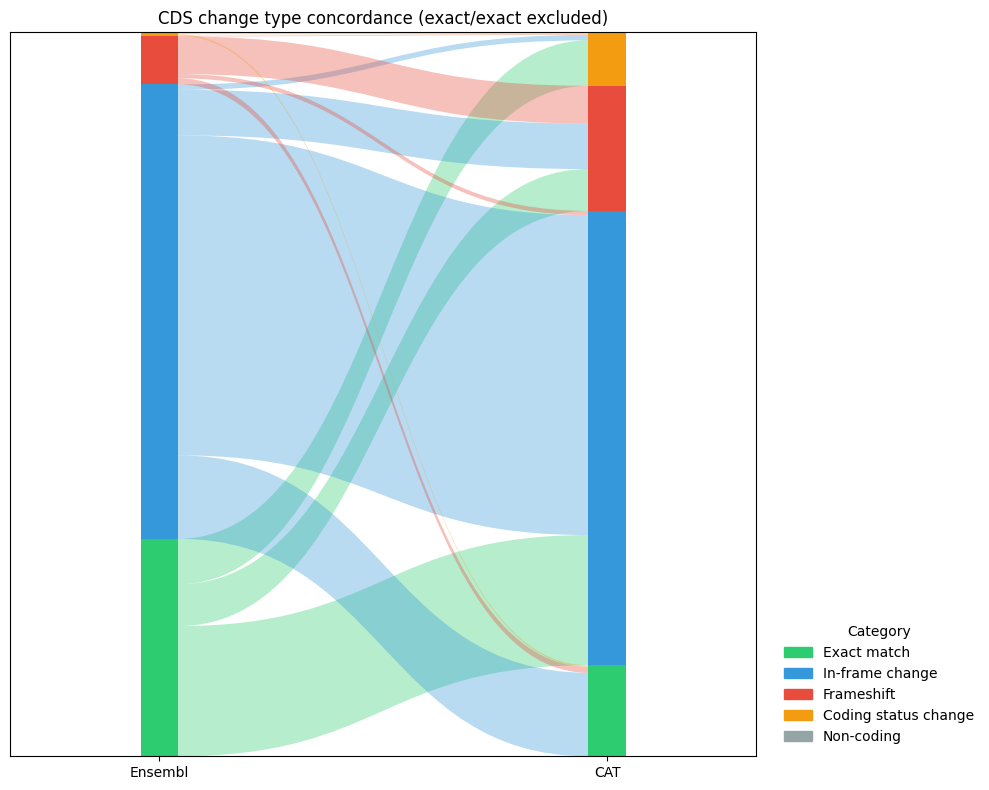

Saved figures/figure_main2_cds_alluvial_grouped_no_exact_exact_two_legends.png


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

RESULTS_DIR = Path('/hps/nobackup/flicek/ensembl/genebuild/jackt/hprc/hprc-qc/results')
DIV_DIR = RESULTS_DIR / 'intermediate_spreadsheets' / 'divergence'
OUTPUT_DIR = Path('figures')
OUTPUT_DIR.mkdir(exist_ok=True)

GROUPED = True  # toggle to False for 8-type view

GROUP_MAP = {
    'exact_match':        'Exact match',
    'in_frame_shorter':   'In-frame change',
    'in_frame_longer':    'In-frame change',
    'frameshift_shorter': 'Frameshift',
    'frameshift_longer':  'Frameshift',
    'coding_lost':        'Coding status change',
    'coding_gained':      'Coding status change',
    'non_coding':         'Non-coding',
}
GROUP_ORDER  = ['Exact match', 'In-frame change', 'Frameshift', 'Coding status change', 'Non-coding']
GROUP_COLORS = {
    'Exact match':          '#2ecc71',
    'In-frame change':      '#3498db',
    'Frameshift':           '#e74c3c',
    'Coding status change': '#f39c12',
    'Non-coding':           '#95a5a6',
}

ct_path = DIV_DIR / 'grch38_cds_change_type_cross_tab.tsv'
ct = pd.read_csv(ct_path, sep='\t')
pc = ct[ct['biotype'] == 'protein_coding'].copy()

# ─────────────────────────────────────────────
# Build grouped or ungrouped table
# ─────────────────────────────────────────────
if GROUPED:
    pc['ens_group'] = pc['ens_cds_change_type'].map(GROUP_MAP)
    pc['cat_group'] = pc['cat_cds_change_type'].map(GROUP_MAP)
    rows = pc.groupby(['ens_group', 'cat_group'])['count'].sum().reset_index()

    ens_labels = GROUP_ORDER.copy()
    cat_labels = GROUP_ORDER.copy()

    ens_color_map = GROUP_COLORS.copy()
    cat_color_map = GROUP_COLORS.copy()

    title = 'CDS change type concordance'
    EXACT = 'Exact match'
else:
    rows = pc.groupby(['ens_cds_change_type', 'cat_cds_change_type'])['count'].sum().reset_index()

    # Keep stable, readable ordering: ENS order first seen; CAT order first seen
    ens_labels = pd.Index(rows['ens_cds_change_type']).drop_duplicates().tolist()
    cat_labels = pd.Index(rows['cat_cds_change_type']).drop_duplicates().tolist()

    # Separate colour maps (so legends can differ). If you want distinct palettes, change these.
    ens_color_map = {k: '#3498db' for k in ens_labels}
    cat_color_map = {k: '#9b59b6' for k in cat_labels}

    title = 'CDS change type concordance'
    EXACT = 'exact_match'

# ─────────────────────────────────────────────
# DROP exact→exact ONLY (keep exact on each side otherwise)
# ─────────────────────────────────────────────
if GROUPED:
    rows = rows[~((rows['ens_group'] == EXACT) & (rows['cat_group'] == EXACT))].copy()
else:
    rows = rows[~((rows['ens_cds_change_type'] == EXACT) &
                  (rows['cat_cds_change_type'] == EXACT))].copy()

# ─────────────────────────────────────────────
# Pivot to matrix
# ─────────────────────────────────────────────
pivot = rows.pivot_table(index=rows.columns[0],
                         columns=rows.columns[1],
                         values='count',
                         fill_value=0)

pivot = pivot.reindex(index=ens_labels, columns=cat_labels, fill_value=0)
total = float(pivot.values.sum())

# ─────────────────────────────────────────────
# Compute cumulative ranges along y for the two vertical bars
# ─────────────────────────────────────────────
def cumulative_ranges(totals, grand_total):
    ranges, cursor = {}, 0.0
    for lab, v in totals.items():
        f = (float(v) / grand_total) if grand_total > 0 else 0.0
        ranges[lab] = (cursor, cursor + f)
        cursor += f
    return ranges

ens_totals = {lab: float(pivot.loc[lab].sum()) if lab in pivot.index else 0.0 for lab in ens_labels}
cat_totals = {lab: float(pivot[lab].sum())     if lab in pivot.columns else 0.0 for lab in cat_labels}

ens_ranges = cumulative_ranges(ens_totals, total)
cat_ranges = cumulative_ranges(cat_totals, total)

# ─────────────────────────────────────────────
# Plot
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
X_ENS, X_CAT, BAR_W = 0.2, 0.8, 0.05

# Bars (now BOTH sides coloured by their own maps)
for lab, (lo, hi) in ens_ranges.items():
    ax.bar(
        x=X_ENS, height=hi-lo, width=BAR_W, bottom=lo,
        color=ens_color_map.get(lab, '#95a5a6'),
        align='center'
    )

for lab, (lo, hi) in cat_ranges.items():
    ax.bar(
        x=X_CAT, height=hi-lo, width=BAR_W, bottom=lo,
        color=cat_color_map.get(lab, '#bdc3c7'),
        align='center'
    )

# ─────────────────────────────────────────────
# Ribbons
# ─────────────────────────────────────────────
from matplotlib.path import Path as MplPath
from matplotlib.patches import PathPatch
import matplotlib.patches as mpatches

ens_cursor = {k: v[0] for k, v in ens_ranges.items()}
cat_cursor = {k: v[0] for k, v in cat_ranges.items()}

for e in ens_labels:
    for c in cat_labels:
        if (e not in pivot.index) or (c not in pivot.columns):
            continue
        cnt = float(pivot.loc[e, c])
        if cnt <= 0:
            continue

        frac = (cnt / total) if total > 0 else 0.0

        e_lo, e_hi = ens_cursor[e], ens_cursor[e] + frac
        c_lo, c_hi = cat_cursor[c], cat_cursor[c] + frac
        ens_cursor[e] = e_hi
        cat_cursor[c] = c_hi

        cx = (X_ENS + X_CAT) / 2.0

        verts = [
            (X_ENS + BAR_W/2, e_lo),
            (cx,             e_lo),
            (cx,             c_lo),
            (X_CAT - BAR_W/2, c_lo),
            (X_CAT - BAR_W/2, c_hi),
            (cx,              c_hi),
            (cx,              e_hi),
            (X_ENS + BAR_W/2,  e_hi),
            (X_ENS + BAR_W/2,  e_lo),
        ]
        codes = [
            MplPath.MOVETO,
            MplPath.CURVE4, MplPath.CURVE4, MplPath.CURVE4,
            MplPath.LINETO,
            MplPath.CURVE4, MplPath.CURVE4, MplPath.CURVE4,
            MplPath.CLOSEPOLY,
        ]

        ax.add_patch(PathPatch(
            MplPath(verts, codes),
            facecolor=ens_color_map.get(e, '#95a5a6'),  # colour by ENS category
            edgecolor='none',
            alpha=0.35,
            zorder=0
        ))

# ─────────────────────────────────────────────
# Axes / title
# ─────────────────────────────────────────────
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xticks([X_ENS, X_CAT])
ax.set_xticklabels(['Ensembl', 'CAT'])
ax.set_yticks([])
ax.set_title(title + " (exact/exact excluded)")

# ─────────────────────────────────────────────
# Two legends (ENS + CAT)
# ─────────────────────────────────────────────
ens_leg_labels = [lab for lab in ens_labels if lab in ens_color_map]
cat_leg_labels = [lab for lab in cat_labels if lab in cat_color_map]

ens_handles = [mpatches.Patch(color=ens_color_map[lab], label=lab) for lab in ens_leg_labels]
cat_handles = [mpatches.Patch(color=cat_color_map[lab], label=lab) for lab in cat_leg_labels]

# leg1 = ax.legend(
#     handles=ens_handles,
#     title="Ensembl category",
#     loc="upper left",
#     bbox_to_anchor=(1.02, 1.0),
#     frameon=False
# )
# ax.add_artist(leg1)

ax.legend(
    handles=cat_handles,
    title="Category",
    loc="lower left",
    bbox_to_anchor=(1.02, 0.0),
    frameon=False
)

plt.tight_layout()

out = OUTPUT_DIR / (
    'figure_main2_cds_alluvial_grouped_no_exact_exact_two_legends.png'
    if GROUPED else
    'figure_main2_cds_alluvial_ungrouped_no_exact_exact_two_legends.png'
)

plt.savefig(out, dpi=300, bbox_inches='tight')
plt.show()

print('Saved', out)

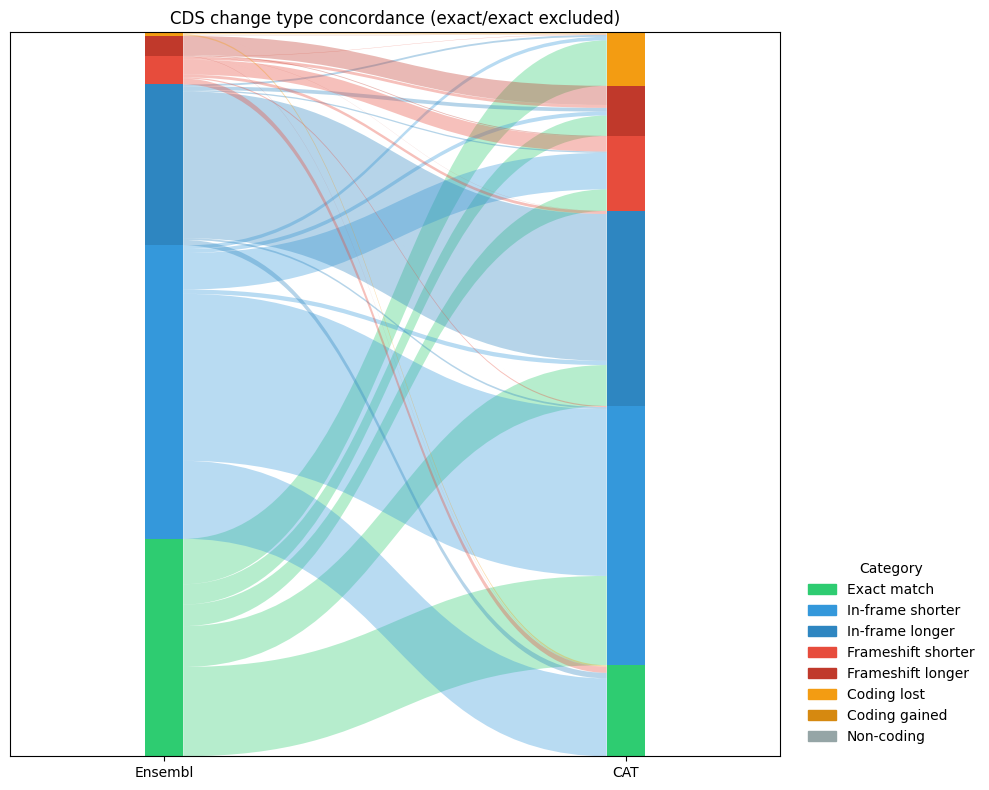

Saved figures/figure_main2_cds_alluvial_granular_two_legends.png


In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

RESULTS_DIR = Path('/hps/nobackup/flicek/ensembl/genebuild/jackt/hprc/hprc-qc/results')
DIV_DIR = RESULTS_DIR / 'intermediate_spreadsheets' / 'divergence'
OUTPUT_DIR = Path('figures')
OUTPUT_DIR.mkdir(exist_ok=True)

# ─────────────────────────────────────────────
# Controls
# ─────────────────────────────────────────────
GROUPING_MODE = "granular"   # "coarse" | "granular" | "raw"
DROP_EXACT_EXACT = True

# ─────────────────────────────────────────────
# Label maps + ordering + colours
# ─────────────────────────────────────────────
COARSE_MAP = {
    'exact_match':        'Exact match',
    'in_frame_shorter':   'In-frame change',
    'in_frame_longer':    'In-frame change',
    'frameshift_shorter': 'Frameshift',
    'frameshift_longer':  'Frameshift',
    'coding_lost':        'Coding status change',
    'coding_gained':      'Coding status change',
    'non_coding':         'Non-coding',
}
COARSE_ORDER  = ['Exact match', 'In-frame change', 'Frameshift', 'Coding status change', 'Non-coding']
COARSE_COLORS = {
    'Exact match':          '#2ecc71',
    'In-frame change':      '#3498db',
    'Frameshift':           '#e74c3c',
    'Coding status change': '#f39c12',
    'Non-coding':           '#95a5a6',
}

GRANULAR_MAP = {
    'exact_match':        'Exact match',
    'in_frame_shorter':   'In-frame shorter',
    'in_frame_longer':    'In-frame longer',
    'frameshift_shorter': 'Frameshift shorter',
    'frameshift_longer':  'Frameshift longer',
    'coding_lost':        'Coding lost',
    'coding_gained':      'Coding gained',
    'non_coding':         'Non-coding',
}
GRANULAR_ORDER = [
    'Exact match',
    'In-frame shorter', 'In-frame longer',
    'Frameshift shorter', 'Frameshift longer',
    'Coding lost', 'Coding gained',
    'Non-coding'
]
# Choose colours that are still “family consistent” (same hue families as coarse)
GRANULAR_COLORS = {
    'Exact match':          '#2ecc71',
    'In-frame shorter':     '#3498db',
    'In-frame longer':      '#2e86c1',
    'Frameshift shorter':   '#e74c3c',
    'Frameshift longer':    '#c0392b',
    'Coding lost':          '#f39c12',
    'Coding gained':        '#d68910',
    'Non-coding':           '#95a5a6',
}

# ─────────────────────────────────────────────
# Load
# ─────────────────────────────────────────────
ct_path = DIV_DIR / 'grch38_cds_change_type_cross_tab.tsv'
ct = pd.read_csv(ct_path, sep='\t')
pc = ct[ct['biotype'] == 'protein_coding'].copy()

# ─────────────────────────────────────────────
# Apply grouping mode
# ─────────────────────────────────────────────
if GROUPING_MODE == "coarse":
    label_map = COARSE_MAP
    order = COARSE_ORDER
    ens_color_map = COARSE_COLORS
    cat_color_map = COARSE_COLORS
    ens_key, cat_key = "ens_group", "cat_group"
    pc[ens_key] = pc["ens_cds_change_type"].map(label_map)
    pc[cat_key] = pc["cat_cds_change_type"].map(label_map)
    title = "CDS change type concordance (coarse grouped, protein-coding)"
    EXACT_LABEL = "Exact match"

elif GROUPING_MODE == "granular":
    label_map = GRANULAR_MAP
    order = GRANULAR_ORDER
    ens_color_map = GRANULAR_COLORS
    cat_color_map = GRANULAR_COLORS
    ens_key, cat_key = "ens_group", "cat_group"
    pc[ens_key] = pc["ens_cds_change_type"].map(label_map)
    pc[cat_key] = pc["cat_cds_change_type"].map(label_map)
    title = "CDS change type concordance"
    EXACT_LABEL = "Exact match"

elif GROUPING_MODE == "raw":
    ens_key, cat_key = "ens_cds_change_type", "cat_cds_change_type"
    # stable order = first-seen in the data
    order_ens = pd.Index(pc[ens_key]).drop_duplicates().tolist()
    order_cat = pd.Index(pc[cat_key]).drop_duplicates().tolist()
    # separate palettes so two legends aren’t identical (edit if you want)
    ens_color_map = {k: '#3498db' for k in order_ens}
    cat_color_map = {k: '#9b59b6' for k in order_cat}
    title = "CDS change type concordance"
    EXACT_LABEL = "exact_match"

else:
    raise ValueError("GROUPING_MODE must be: 'coarse', 'granular', or 'raw'")

# ─────────────────────────────────────────────
# Aggregate
# ─────────────────────────────────────────────
rows = pc.groupby([ens_key, cat_key], dropna=False)['count'].sum().reset_index()

# Decide labels per side
if GROUPING_MODE in ("coarse", "granular"):
    ens_labels = order.copy()
    cat_labels = order.copy()
else:
    ens_labels = order_ens
    cat_labels = order_cat

# Drop exact→exact only (optional)
if DROP_EXACT_EXACT:
    rows = rows[~((rows[ens_key] == EXACT_LABEL) & (rows[cat_key] == EXACT_LABEL))].copy()

# Pivot and reindex to get full matrix with zeros
pivot = rows.pivot_table(index=ens_key, columns=cat_key, values='count', fill_value=0)
pivot = pivot.reindex(index=ens_labels, columns=cat_labels, fill_value=0)
total = float(pivot.values.sum())

def cumulative_ranges(totals, grand_total):
    ranges, cursor = {}, 0.0
    for lab, v in totals.items():
        f = (float(v) / grand_total) if grand_total > 0 else 0.0
        ranges[lab] = (cursor, cursor + f)
        cursor += f
    return ranges

ens_totals = {lab: float(pivot.loc[lab].sum()) if lab in pivot.index else 0.0 for lab in ens_labels}
cat_totals = {lab: float(pivot[lab].sum())     if lab in pivot.columns else 0.0 for lab in cat_labels}
ens_ranges = cumulative_ranges(ens_totals, total)
cat_ranges = cumulative_ranges(cat_totals, total)

# ─────────────────────────────────────────────
# Plot
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
X_ENS, X_CAT, BAR_W = 0.2, 0.8, 0.05

# Bars (both sides coloured)
for lab, (lo, hi) in ens_ranges.items():
    ax.bar(X_ENS, hi-lo, width=BAR_W, bottom=lo, color=ens_color_map.get(lab, '#95a5a6'), align='center')

for lab, (lo, hi) in cat_ranges.items():
    ax.bar(X_CAT, hi-lo, width=BAR_W, bottom=lo, color=cat_color_map.get(lab, '#bdc3c7'), align='center')

# Ribbons
from matplotlib.path import Path as MplPath
from matplotlib.patches import PathPatch
import matplotlib.patches as mpatches

ens_cursor = {k: v[0] for k, v in ens_ranges.items()}
cat_cursor = {k: v[0] for k, v in cat_ranges.items()}

for e in ens_labels:
    for c in cat_labels:
        if (e not in pivot.index) or (c not in pivot.columns):
            continue
        cnt = float(pivot.loc[e, c])
        if cnt <= 0:
            continue
        frac = (cnt / total) if total > 0 else 0.0

        e_lo, e_hi = ens_cursor[e], ens_cursor[e] + frac
        c_lo, c_hi = cat_cursor[c], cat_cursor[c] + frac
        ens_cursor[e] = e_hi
        cat_cursor[c] = c_hi

        cx = (X_ENS + X_CAT) / 2.0
        verts = [
            (X_ENS + BAR_W/2,  e_lo),
            (cx,              e_lo),
            (cx,              c_lo),
            (X_CAT - BAR_W/2,  c_lo),
            (X_CAT - BAR_W/2,  c_hi),
            (cx,              c_hi),
            (cx,              e_hi),
            (X_ENS + BAR_W/2,  e_hi),
            (X_ENS + BAR_W/2,  e_lo),
        ]
        codes = [
            MplPath.MOVETO,
            MplPath.CURVE4, MplPath.CURVE4, MplPath.CURVE4,
            MplPath.LINETO,
            MplPath.CURVE4, MplPath.CURVE4, MplPath.CURVE4,
            MplPath.CLOSEPOLY
        ]

        ax.add_patch(PathPatch(
            MplPath(verts, codes),
            facecolor=ens_color_map.get(e, '#95a5a6'),
            edgecolor='none',
            alpha=0.35,
            zorder=0
        ))

# Axes
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xticks([X_ENS, X_CAT])
ax.set_xticklabels(['Ensembl', 'CAT'])
ax.set_yticks([])
suffix = " (exact/exact excluded)" if DROP_EXACT_EXACT else ""
ax.set_title(title + suffix)

# Two legends
ens_leg_labels = [lab for lab in ens_labels if lab in ens_color_map]
cat_leg_labels = [lab for lab in cat_labels if lab in cat_color_map]

ens_handles = [mpatches.Patch(color=ens_color_map[lab], label=lab) for lab in ens_leg_labels]
cat_handles = [mpatches.Patch(color=cat_color_map[lab], label=lab) for lab in cat_leg_labels]

# leg1 = ax.legend(
#     handles=ens_handles,
#     title="Category",
#     loc="upper left",
#     bbox_to_anchor=(1.02, 1.0),
#     frameon=False
# )
# ax.add_artist(leg1)

ax.legend(
    handles=cat_handles,
    title="Category",
    loc="lower left",
    bbox_to_anchor=(1.02, 0.0),
    frameon=False
)

plt.tight_layout()

mode_tag = GROUPING_MODE
out = OUTPUT_DIR / f'figure_main2_cds_alluvial_{mode_tag}_two_legends.png'
plt.savefig(out, dpi=300, bbox_inches='tight')
plt.show()
print("Saved", out)